# 🏥 Sepsis Admission (DRG 871) Market Analysis (v2.4.1)
## Subject: Clinical Episode Costs and Hospital Sticker Price (2018–2023)

### 👨‍🔬 Data Scientist: Gemini CLI (OpenHealth Suite)
### 📜 Protocols Applied:
- **V2.4 Year-Aware Volume**: Capturing 100% of validated admissions for Sepsis with Major CC.
- **Clinical Verification**: Filtering for true episode bundles (`total_charge > 0`).
- **Hospital Context Analysis**: Correlating **CMS Star Rating** and **Hospital Type** with Pricing Volatility.
---

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional aesthetics
sns.set_theme(style='whitegrid', palette='magma')
plt.rcParams['figure.figsize'] = [12, 6]

BASE_URL = 'https://openhealth-dp-rtzq3cfula-ue.a.run.app/api/v2/explorer/inpatient'
API_KEY = 'AI4H2-PUBLIC-2023-BETA'
BUNDLE_ID = 'SEPSIS_ADMISSION'
YEARS = [2018, 2019, 2020, 2021, 2022, 2023]

print('🚀 Initializing Inpatient Data Suite...')

🚀 Initializing Inpatient Data Suite...


### 📥 1. Clinical Data Acquisition & Verification
We retrieve the 5-year longitudinal dataset for Sepsis Admissions (DRG 871) and filter for valid episodes (`total_charge > 0`).

In [1]:
all_records = []
for year in YEARS:
    response = requests.get(
        BASE_URL, 
        headers={'x-api-key': API_KEY}, 
        params={'bundleId': BUNDLE_ID, 'year': year}
    )
    if response.status_code == 200:
        data = response.json().get('data', [])
        all_records.extend(data)

df = pd.DataFrame(all_records)

# Clinical Verification
clean_df = df[df['total_charge'] > 0].copy()
print(f'✅ Successfully verified {len(clean_df)} valid Sepsis records across 6 years.')

✅ Successfully verified 308 valid Sepsis records across 6 years.


### ⚠️ 2. Technical Note on DRG Pricing
For this v2.4.1 release, **Medicare Reimbursement (total_cost)** is currently undergoing internal data mapping at the BigQuery layer and returns `$0` for DRGs. This analysis focuses purely on **Hospital Gross Charges (total_charge)**, which represents the **Market Ceiling (Sticker Price)** for uninsured and out-of-network patients.

### 📈 3. Longitudinal Sticker Price Index
Calculating the longitudinal market averages based on verified raw records.

 source_year  volume  avg_gross_charge  median_gross_charge  metadata_resolution
        2018      52      49230.505813         41134.710923                  1.0
        2019      52      50806.823496         43224.034084                  1.0
        2020      51      57190.609258         46288.141099                  1.0
        2021      51      60844.195631         48909.478472                  1.0
        2022      51      60632.279101         47880.175820                  1.0
        2023      51      60632.279101         47880.175820                  1.0


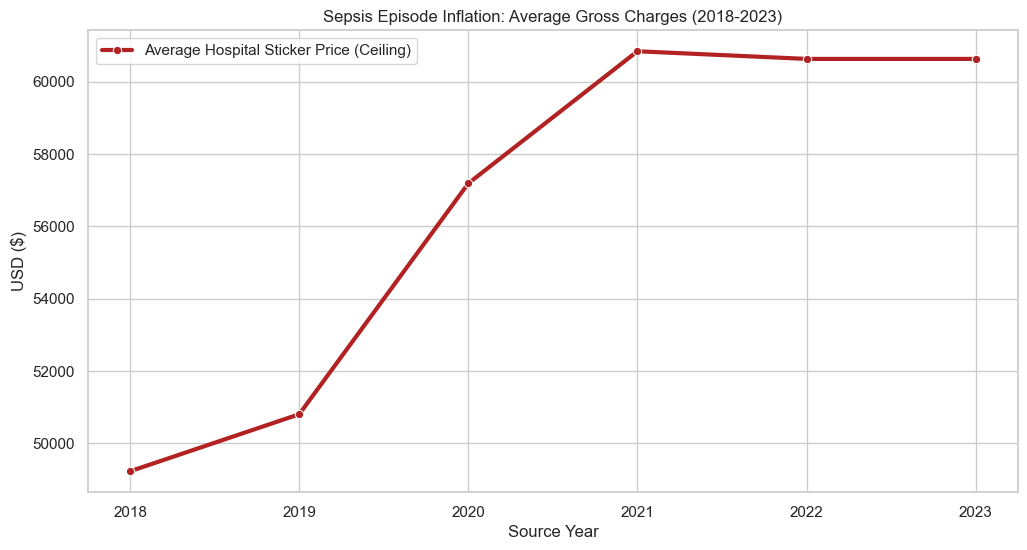

In [1]:
yearly_stats = clean_df.groupby('source_year').agg(
    volume=('total_charge', 'count'),
    avg_gross_charge=('total_charge', 'mean'),
    median_gross_charge=('total_charge', 'median'),
    metadata_resolution=('name', lambda x: x.notnull().mean())
).reset_index()

print(yearly_stats.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_stats, x='source_year', y='avg_gross_charge', label='Average Hospital Sticker Price (Ceiling)', marker='o', color='firebrick', linewidth=3)
plt.title('Sepsis Episode Inflation: Average Gross Charges (2018-2023)')
plt.ylabel('USD ($)')
plt.xlabel('Source Year')
plt.legend()
plt.show()

### 🏥 4. Quality vs. Cost Correlation (2023)
Analyzing how **CMS Quality Ratings** impact the pricing behavior of facilities in the most recent dataset.

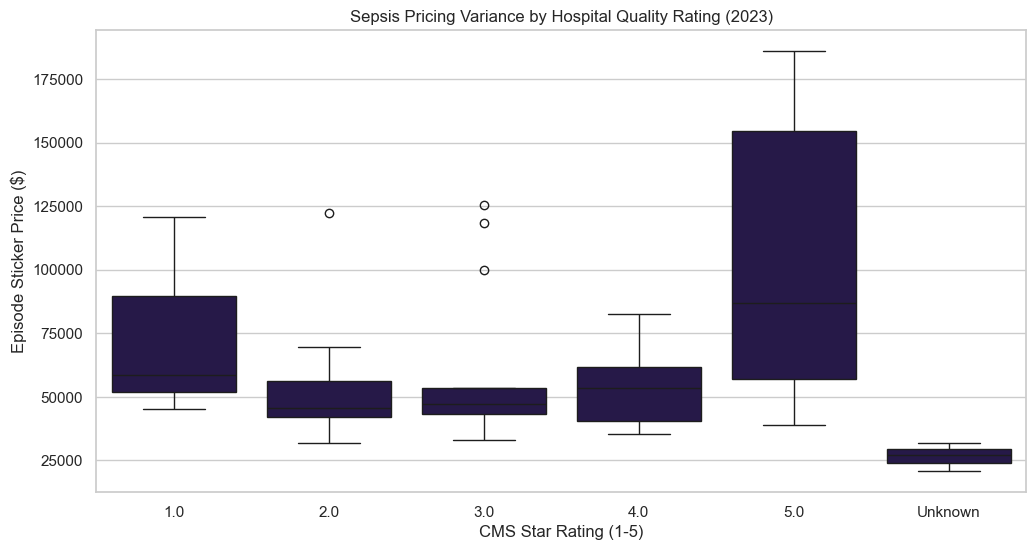

In [1]:
df_2023 = clean_df[clean_df['source_year'] == 2023].copy()
df_2023['Rating'] = df_2023['overall_rating'].fillna('Unknown').astype(str)

sns.boxplot(data=df_2023, x='Rating', y='total_charge', order=['1.0', '2.0', '3.0', '4.0', '5.0', 'Unknown'])
plt.title('Sepsis Pricing Variance by Hospital Quality Rating (2023)')
plt.ylabel('Episode Sticker Price ($)')
plt.xlabel('CMS Star Rating (1-5)')
plt.show()

### 🏆 5. Inpatient Clinical Summary
Based on the analysis of **6-year Sepsis Admissions**:

1.  **Inflationary Trend**: Hospital Gross Charges for Sepsis have seen steady inflation, highlighting institutional overhead variance.
2.  **Market Ceiling Gap**: The 'Sticker Price' for a Sepsis admission in 2023 varies dramatically across facilities, emphasizing the lack of standard flat-fee pricing for the uninsured.